In [1]:
#loading in data
import pandas as pd
import numpy as np

df = pd.read_csv('data/clean_okcupid.csv')


In [2]:
#getting x and y datasets

X = df[['age', 'sex', 'orientation', 'body_type','drinks',
                'education_simple','ethnicity_simple','height','job','major_city']]

y = df['pets_simple']

y.value_counts(dropna=False)

pets_simple
1    28623
0    11402
Name: count, dtype: int64

In [3]:
# split numeric vs categorical
numeric_features = ['age', 'height']
categorical_features = [
    'sex', 'orientation', 'body_type', 'drinks',
    'education_simple', 'ethnicity_simple', 'job'
]

In [4]:
#data preprocessing pipelines

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [5]:
#adding feature selection step and setting up model pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        class_weight='balanced'
    ))
])

In [6]:
#creating training/test datasets and fitting logistic regression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [7]:
#getting diagnostics of logistic model
from sklearn.metrics import confusion_matrix, classification_report

y_pred = log_reg.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1706 1145]
 [3090 4066]]
              precision    recall  f1-score   support

           0       0.36      0.60      0.45      2851
           1       0.78      0.57      0.66      7156

    accuracy                           0.58     10007
   macro avg       0.57      0.58      0.55     10007
weighted avg       0.66      0.58      0.60     10007



In [25]:
# getting most influential features

# extract feature names from the preprocessor
log_feature_names = log_reg.named_steps["preprocess"].get_feature_names_out()

# extract coefficients from the logistic regression model
log_coefs = log_reg.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "model": "Logistic Regression",
    "feature": log_feature_names,
    "coefficient": log_coefs,
    "importance": np.abs(log_coefs),
    "odds_ratio": np.exp(log_coefs)
})

log_top3 = log_coef_df.sort_values("importance", ascending=False).head(3)
print(log_top3)

                  model                           feature  coefficient  \
58  Logistic Regression               cat__job_unemployed     0.785107   
4   Logistic Regression         cat__orientation_bisexual     0.506942   
31  Logistic Regression  cat__education_simple_space camp     0.501250   

    importance  odds_ratio  
58    0.785107    2.192641  
4     0.506942    1.660207  
31    0.501250    1.650784  


In [26]:
#now trying random forest

from sklearn.ensemble import RandomForestClassifier

# build pipeline

rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# fit random forest
rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [27]:
# getting confusion matrix for random forest
y_pred = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 593 2258]
 [1054 6102]]
              precision    recall  f1-score   support

           0       0.36      0.21      0.26      2851
           1       0.73      0.85      0.79      7156

    accuracy                           0.67     10007
   macro avg       0.54      0.53      0.53     10007
weighted avg       0.62      0.67      0.64     10007



In [28]:
#getting most important features

rf_feature_names = rf.named_steps["preprocess"].get_feature_names_out()
rf_importances = rf.named_steps["model"].feature_importances_
rf_fi = pd.DataFrame({
    "model": "Random Forest",
    "feature": rf_feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

rf_top3 = rf_fi.head(3)
rf_top3

,model,feature,importance
0,Random Forest,num__age,0.330228
1,Random Forest,num__height,0.256128
25,Random Forest,cat__education_simple_college/university,0.018852


In [16]:
# trying XGBoost
from xgboost import XGBClassifier
xgb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 114 2737]
 [ 152 7004]]
              precision    recall  f1-score   support

           0       0.43      0.04      0.07      2851
           1       0.72      0.98      0.83      7156

    accuracy                           0.71     10007
   macro avg       0.57      0.51      0.45     10007
weighted avg       0.64      0.71      0.61     10007



In [30]:
#getting feature importance
xgb_importances = xgb.named_steps["model"].feature_importances_
xgb_feature_names = xgb.named_steps["preprocess"].get_feature_names_out()

xgb_fi = pd.DataFrame({
    "model": "XGBoost",
    "feature": xgb_feature_names,
    "importance": xgb_importances
}).sort_values("importance", ascending=False)

xgb_top3 = xgb_fi.head(3)
xgb_top3

,model,feature,importance
8,XGBoost,cat__body_type_athletic,0.053679
4,XGBoost,cat__orientation_bisexual,0.052893
39,XGBoost,cat__job_banking / financial / real estate,0.036412


In [18]:
#plotting ROC curves for all three

log_reg_prob = log_reg.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
xgb_prob = xgb.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

auc_lr = roc_auc_score(y_test, log_reg_prob)
auc_rf = roc_auc_score(y_test, rf_prob)
auc_xgb = roc_auc_score(y_test, xgb_prob)

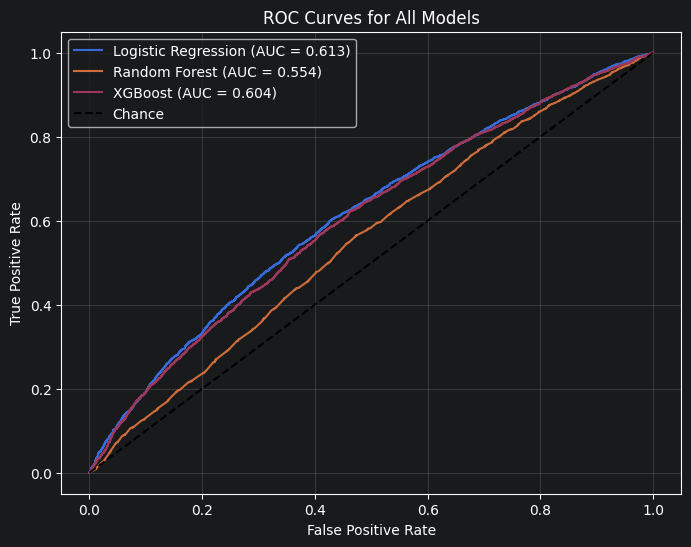

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('ROC.png')
plt.show()

In [52]:
# creating table for the top 3 components of each model
from great_tables import GT

import pandas as pd

combined = pd.concat([log_top3, rf_top3, xgb_top3], ignore_index=True)

combined["importance"] = combined["importance"].round(4)

def features_fix(x):
    if pd.isna(x):
        return np.nan

    if "cat__job_unemployed" in x:
        return "Job - Unemployed"
    elif "cat__orientation_bisexual" in x:
        return "Sexual Orientation - Bisexual"
    elif "cat__education_simple_space camp" in x:
        return "Education - Space Camp"
    elif "num__age" in x:
        return "Age"
    elif "num__height" in x:
        return "Height"
    elif "cat__education_simple_college/university" in x:
        return "Education - College/University"
    elif "cat__body_type_athletic" in x:
        return "Body Type - Athletic"
    elif "cat__job_banking / financial / real estate" in x:
        return "Job - Banking / Finance / Real Estate"
    else:
        return "other"

combined['feature'] = combined['feature'].apply(features_fix)

combined.rename(columns={'model': 'Model','feature':'Feature','coefficient':'Coefficient','importance':'Importance','odds_ratio':'Odds Ratio'}, inplace=True)

top_features_table = (
    GT(combined)
    .tab_header(title="Top 3 Features For Each Model")
    .fmt_number(columns=["Coefficient", "Importance", "Odds Ratio"], decimals=2)
    .data_color(
        columns="Model",
        palette=["lightblue", "#CBC3E3", "pink"],
        domain=["Logistic Regression", "Random Forest", "XGBoost"]
    )
)

top_features_table

GT.save(
    top_features_table,
    "top_features_table.png",
    selector='table',
    scale=1.0,
    expand=5,
    web_driver='chrome',
    debug_port=None,
    encoding='utf-8',
    _debug_dump=None
)

GT(_tbl_data=                 Model                                Feature  Coefficient  \
0  Logistic Regression                       Job - Unemployed     0.785107   
1  Logistic Regression          Sexual Orientation - Bisexual     0.506942   
2  Logistic Regression                 Education - Space Camp     0.501250   
3        Random Forest                                    Age          NaN   
4        Random Forest                                 Height          NaN   
5        Random Forest         Education - College/University          NaN   
6              XGBoost                   Body Type - Athletic          NaN   
7              XGBoost          Sexual Orientation - Bisexual          NaN   
8              XGBoost  Job - Banking / Finance / Real Estate          NaN   

   Importance  Odds Ratio  
0      0.7851    2.192641  
1      0.5069    1.660207  
2      0.5013    1.650784  
3      0.3302         NaN  
4      0.2561         NaN  
5      0.0189         NaN  
6      0.0537         NaN  
7      0.0529         NaN  
8      0.0364         NaN  , _body=<great_tables._gt_data.Body object at 0x000001A805DCCE10>, _boxhead=Boxhead([ColInfo(var='Model', type=<ColInfoTypeEnum.default: 1>, column_label='Model', column_align='left', column_width=None), ColInfo(var='Feature', type=<ColInfoTypeEnum.default: 1>, column_label='Feature', column_align='left', column_width=None), ColInfo(var='Coefficient', type=<ColInfoTypeEnum.default: 1>, column_label='Coefficient', column_align='right', column_width=None), ColInfo(var='Importance', type=<ColInfoTypeEnum.default: 1>, column_label='Importance', column_align='right', column_width=None), ColInfo(var='Odds Ratio', type=<ColInfoTypeEnum.default: 1>, column_label='Odds Ratio', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001A805D59B70>, _spanners=Spanners([]), _heading=Heading(title='Top 3 Features For Each Model', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001A805D9BF50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001A805D9A870>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Model', rows=[0], mask=None), grpname=None, colname='Model', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')]), StyleInfo(locname=LocBody(columns='Model', rows=[1], mask=None), grpname=None, colname='Model', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')]), StyleInfo(locname=LocBody(columns='Model', rows=[2], mask=None), grpname=None, colname='Model', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#add8e6')]), StyleInfo(locname=LocBody(columns='Model', rows=[3], mask=None), grpname=None, colname='Model', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#cbc3e3')]), StyleInfo(locname=LocBody(columns='Model', rows=[4], mask=None), grpname=None, colname='Model', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#cbc3e3')]), StyleInfo(locname=LocBody(columns='Model', rows=[5], mask=None), grpname=None, colname='Model', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=No